In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import numpy.linalg as la
import random

In [3]:
# Constructing the desired matrices

def get_Matern_covariance(data, kappa, s):
    """
    data: N x D array of N vectors x_i in R^D
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns a N x N matrix M with M_ij = C_Mat(x_i, x_j)
    """

    dim = data.shape[1]
    nu = s - dim/2
    sigma2 = gamma(nu)/(gamma(s)*(4*np.pi)**(dim/2))
    scalar = sigma2*(2**(1-nu)/gamma(nu))

    # matrix of pairwise distances
    D = kappa*np.linalg.norm(data[:, None] - data[None, :], axis = -1)

    M = np.zeros(D.shape)
    off_diag = (D > 0)
    M[off_diag] = scalar * (D[off_diag] ** nu) * kv(nu, D[off_diag])
    M[~off_diag] = sigma2

    return M

def get_mass_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(1, n_h-1)
    diag = np.full(n_h, 4)
    diag[0] = diag[-1] = 2
    M = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (h/6)*M

"""
def get_lumped_mass_matrix(M, n_h):
    M = get_mass_matrix(n_h)
    return np.diag(M.sum(axis = 1))
"""


def get_stiffness_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(-1, n_h-1)
    diag = np.full(n_h, 2)
    diag[0] = diag[-1] = 1
    G = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (1/h)*G

def get_FE_precision_matrix(M, G, kappa, s):
    """
    M: FE mass matrix with M_ij = <e_{h,i}, e_{h,j}>_2
    M_tilde: Lumped FE mass matrix
    G: FE stiffness matrix with G_{ij} = <grad(e_{h,i}), grad(e_{h,j})>_2
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns the precision matrix (k^2M + G)[M_tilde^{-1}(k^2M+G)]^{s-1}
    """

    #M_tilde = np.diag(M.sum(axis = 1)) #lumping
    block1 = kappa**2 * M + G
    #print("rank of block1 is {r} and dimension is {d}".format(r = la.matrix_rank(block1), d = block1.shape))
    block2 = la.solve(M, block1)

    #return la.matmul(block1, block2**(s-1))
    return block1 @ la.matrix_power(block2, s-1)

def get_FE_design_matrix(data, n_h, L):
    """
    data: N x D array of N vectors x_i in R^D

    Return N x n_h finite element design matrix S with S_ij = e_j(X_i)
    """

    K = n_h - 1
    h = L/K
    S = np.zeros((data.shape[0], n_h))
    for i in range(data.shape[0]):
        x_i = data[i,:].item()
        j = int(np.floor(x_i/h)) # get index in the partition
        S[i,j] = -x_i/h + j + 1
        S[i, j+1] = x_i/h - j
    return S

In [4]:
# ground truth and comparison vectors

def get_ground_truth_vector(data, L, kappa, s, M):

    N = len(data)

    # Independent N(0,1) coefficients
    xi = np.random.randn(M + 1)
    zeta = np.random.randn(M + 1)

    # Constant term
    f_0 = np.full(N, xi[0] / np.sqrt(kappa * L))

    # i = 1,...,M
    i = np.arange(1, M + 1)

    eigenvalues = kappa**2 + (i * np.pi / L)**2

    coefficients = (
        np.sqrt(2 / L)
        * kappa**(s - 0.5)
        * eigenvalues**(-s / 2)
    )

    # N x M matrix
    cos_terms = np.cos(np.outer(data, i * np.pi / L))
    sin_terms = np.sin(np.outer(data, i * np.pi / L))

    # Add the KL expansion
    f_0 += (
        cos_terms @ (coefficients * xi[1:])
        + sin_terms @ (coefficients * zeta[1:])
    )

    return f_0

In [18]:

def generate_Matern_posterior(N, kappa, s, tau, data, y):
    """
    N: sample size
    L: upper limit of domain
    n_h: number of finite element basis functions
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation
    tau: standard deviation of likelihood for GP regression

    Returns posterior vectors F_cf, F_fe in R^N with data generated from Uniform(0,L)
    """

    I_N = np.eye(N)
    Sigma = get_Matern_covariance(data, kappa, s)
    block1 = Sigma + (tau**2)*I_N
    F_cf = Sigma @ la.solve(block1, y)
    return F_cf

def generate_finite_element_posterior(N, L, n_h, kappa, s, tau, data, y):
    M, G = get_mass_matrix(n_h, L), get_stiffness_matrix(n_h, L)
    Q = get_FE_precision_matrix(M, G, kappa, s)
    S = get_FE_design_matrix(data, n_h, L)
    block2 = S.T @ S + (tau**2)*Q
    F_fe = S @ la.solve(block2, S.T @ y)
    return F_fe

In [19]:
# data generation

np.random.seed(666)

N = 5000
L = 5
kappa = 1
s = 2
#tau = 2
M = 5000

data = np.random.uniform(0, L, N)
data = data.reshape((N, 1))
f_0 = get_ground_truth_vector(data, L, kappa, s, M)
tau = (0.1)*la.vector_norm(f_0)/np.sqrt(N)
eta = tau*np.random.standard_normal(N)
y = f_0.reshape(N,) + eta

In [ ]:
F_cf = generate_Matern_posterior(N, kappa, s, tau, data, y)

nums = np.arange(2, 300, 5)
nums = [int(num) for num in nums]
errs_cf, errs_fe = [la.norm(F_cf - f_0)/np.sqrt(N)]*len(nums), []
for n_h in nums:
    F_fe = generate_finite_element_posterior(N, L, n_h, kappa, s, tau, data, y)
    errs_fe.append(la.norm(F_fe - f_0)/np.sqrt(N))
    print(n_h, errs_cf[-1], errs_fe[-1])

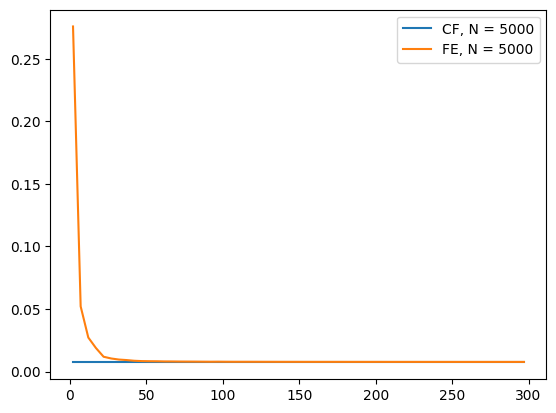

In [21]:
plot_data = np.array([nums, errs_cf, errs_fe])
plt.plot(plot_data[0], plot_data[1], label = "CF, N = 5000")
plt.plot(plot_data[0], plot_data[2], label = "FE, N = 5000")
plt.legend(loc = "upper right")
#plt.ylim(0.0, 0.1)
plt.show()